In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

from utils.plotting import style

DATA_DIR = "/Users/jurajmarusic/Desktop/sDPBO"

C_DP = "#1f77b4"     # DP-GIBO (default μ)
C_DP_ALT = "#ff7f0e"  # DP-GIBO (alt μ)
C_NONDP = "gray"      # GIBO (non-private)
C_RAND = "#2ca02c"    # Random baseline

USETEX = False  # flip to True if you have a LaTeX install
RNG = np.random.default_rng(0)

## Figure 1 — Ablations (left panel)

2×2 grid of hyperparameter sweeps. Designed for `~0.6\textwidth` so it sits next to Figure 2.

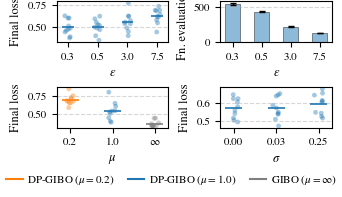

In [2]:
plt.rcParams.update(style.neurips(usetex=USETEX, rel_width=0.6, nrows=2, ncols=2))

with open(f"{DATA_DIR}/all_losses_dp_gibo_varyingepsilons_10reps_four2.pkl", "rb") as f:
    data_eps_loss = pickle.load(f)
with open(f"{DATA_DIR}/all_batches_dp_gibo_varyingepsilons_10reps_four2.pkl", "rb") as f:
    data_eps_batches = pickle.load(f)
with open(f"{DATA_DIR}/all_losses_dp_gibo_varyingmus.pkl", "rb") as f:
    data_mus = pickle.load(f)
with open(f"{DATA_DIR}/all_losses_003.pkl", "rb") as f:
    data_sigmas = pickle.load(f)

epsilons = [0.3, 0.5, 3.0, 7.5]
mus = [0.2, 1.0, 10000.0]
mus_plot = ["0.2", "1.0", r"$\infty$"]
mu_colors = [C_DP_ALT, C_DP, C_NONDP]
mu_labels = [
    r"DP-GIBO ($\mu = 0.2$)",
    r"DP-GIBO ($\mu = 1.0$)",
    r"GIBO ($\mu = \infty$)",
]
sigmas = [0.00, 0.03, 0.25]


def jittered_scatter(ax, finals, i, color):
    x_base = np.full_like(finals, i, dtype=float)
    jitter = (RNG.random(len(finals)) - 0.5) * 0.2
    ax.scatter(x_base + jitter, finals, color=color, alpha=0.4, s=12, edgecolors="none")
    ax.hlines(finals.mean(), i - 0.2, i + 0.2, color=color, lw=1.2)


fig, axes = plt.subplots(2, 2, constrained_layout=True)

# (0,0): ε → final loss
ax = axes[0, 0]
for i, eps in enumerate(epsilons):
    jittered_scatter(ax, data_eps_loss[eps][:, -1], i, C_DP)
ax.set_xticks(range(len(epsilons)))
ax.set_xticklabels([f"{e:.1f}" for e in epsilons])
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel("Final loss")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# (0,1): ε → function evaluations
ax = axes[0, 1]
means, ci_h = [], []
for eps in epsilons:
    finals = data_eps_batches[eps][:, :].sum(axis=1)
    se = stats.sem(finals)
    h = se * stats.t.ppf(0.975, len(finals) - 1)
    means.append(finals.mean())
    ci_h.append(h)
ax.bar(
    np.arange(len(epsilons)),
    means,
    yerr=ci_h,
    capsize=2,
    width=0.5,
    alpha=0.5,
    color=C_DP,
    edgecolor="black",
    linewidth=0.6,
    error_kw=dict(elinewidth=1, ecolor="black"),
)
ax.set_xticks(range(len(epsilons)))
ax.set_xticklabels([f"{e:.1f}" for e in epsilons])
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel("Fn. evaluations")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# (1,0): μ → final loss
ax = axes[1, 0]
for i, (mu, c) in enumerate(zip(mus, mu_colors)):
    jittered_scatter(ax, data_mus[mu][:, -1], i, c)
ax.set_xticks(range(len(mus)))
ax.set_xticklabels(mus_plot)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Final loss")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# (1,1): σ → final loss
ax = axes[1, 1]
for i, sigma in enumerate(sigmas):
    jittered_scatter(ax, data_sigmas[sigma][20:30, -1], i, C_DP)
ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([f"{s:.2f}" for s in sigmas])
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("Final loss")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# shared legend (μ-panel colours) below the figure
legend_handles = [
    Line2D([0], [0], color=col, lw=1.5, label=lab)
    for col, lab in zip(mu_colors, mu_labels)
]
fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=3,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.2,
    handletextpad=0.4,
)

fig.savefig("Main_plot_left.pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig("Main_plot_left.png", bbox_inches="tight", pad_inches=0.02, dpi=300)
plt.show()

## Figure 2 — Trajectories (right panel)

2×1 grid: validation-loss curves and hyperparameter paths. Designed for `~0.4\textwidth`.

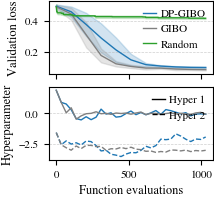

In [3]:
plt.rcParams.update(style.neurips(usetex=USETEX, rel_width=0.4, nrows=2, ncols=1))
# match height of Figure 1 (≈2.04 in) when both are scaled to 0.6/0.4 textwidth in LaTeX
plt.rcParams["figure.figsize"] = (2.2, 2.04)

losses_dp = np.load(f"{DATA_DIR}/losses_dp_gibo_15May.npy")
losses_dp2 = np.load(f"{DATA_DIR}/losses_dp_gibo2_15May.npy")
losses_rd = np.load(f"{DATA_DIR}/losses_random_15May.npy")

num_iter = 5
path_length = 10
d = 103

mean_dp = losses_dp.mean(axis=0)
ci_dp = 1.96 * losses_dp.std(axis=0) / np.sqrt(num_iter)
mean_dp2 = losses_dp2.mean(axis=0)
ci_dp2 = 1.96 * losses_dp2.std(axis=0) / np.sqrt(num_iter)
mean_rd = losses_rd.mean(axis=0)
ci_rd = 1.96 * losses_rd.std(axis=0) / np.sqrt(num_iter)

bs = d
rand_len = path_length * bs
x_dp = np.arange(0, rand_len + bs, bs)
x_rd = np.arange(rand_len)

fig, axes = plt.subplots(2, 1, sharex=True, constrained_layout=True)

# top: validation loss vs function evaluations
ax = axes[0]
ax.plot(x_dp, mean_dp, lw=1, color=C_DP, label="DP-GIBO")
ax.fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2, color=C_DP)
ax.plot(x_dp, mean_dp2, lw=1, color=C_NONDP, label="GIBO")
ax.fill_between(x_dp, mean_dp2 - ci_dp2, mean_dp2 + ci_dp2, alpha=0.2, color=C_NONDP)
ax.plot(x_rd, mean_rd, lw=1, color=C_RAND, label="Random")
ax.fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2, color=C_RAND)
ax.set_ylabel("Validation loss")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False, loc="upper right", handlelength=1.2, handletextpad=0.4, borderaxespad=0.3)

# bottom: hyperparameter paths
ax = axes[1]
path_dp1 = np.load(f"{DATA_DIR}/dp-path1.npy")
path_nondp1 = np.load(f"{DATA_DIR}/nondp-path1.npy")
path_dp2 = np.load(f"{DATA_DIR}/dp-path2.npy")
path_nondp2 = np.load(f"{DATA_DIR}/nondp-path2.npy")

bs_p = d / 3
rand_len_p = 30 * bs_p
x_path = np.arange(0, rand_len_p + bs_p, bs_p)

ax.plot(x_path, path_dp1, lw=1, color=C_DP)
ax.plot(x_path, path_nondp1, lw=1, color=C_NONDP)
ax.plot(x_path, path_dp2, lw=1, linestyle="--", color=C_DP)
ax.plot(x_path, path_nondp2, lw=1, linestyle="--", color=C_NONDP)
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Hyperparameter")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

style_proxies = [
    Line2D([0], [0], color="black", lw=1, linestyle="-", label="Hyper 1"),
    Line2D([0], [0], color="black", lw=1, linestyle="--", label="Hyper 2"),
]
ax.legend(handles=style_proxies, frameon=False, loc="upper right", handlelength=1.2, handletextpad=0.4, borderaxespad=0.3)

fig.savefig("Main_plot_right.pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig("Main_plot_right.png", bbox_inches="tight", pad_inches=0.02, dpi=300)
plt.show()